# Análise Exploratória de Dados (EDA)

O objetivo desta Análise Exploratória é compreender a estrutura, os padrões, os relacionamentos e possíveis anomalias presentes nos dados. Esse entendimento servirá de base para a etapa de feature engineering e para a construção da Analytical Base Table (ABT), que será utilizada no treinamento dos modelos de machine learning.

Carregando os arquivos em parquet e criação de uma função helper para ter uma visão geral do dataframe.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path
import yaml


def find_project_root(marker="DataPipeline/config.yml"):
    p = Path.cwd().resolve()

    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate

    raise FileNotFoundError(
        "Raiz do projeto não encontrada (DataPipeline/config.yml ausente)."
    )


# Carrega a configuração do projeto
PROJECT_ROOT = find_project_root()

with open(PROJECT_ROOT / "DataPipeline" / "config.yml", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

# Diretório da camada clean
CLEAN_DIR = PROJECT_ROOT / cfg["paths"]["clean_dir"]

# Carrega as tabelas sanitizadas
clean_files = cfg["data"]["clean_files"]

df_application = pd.read_parquet(CLEAN_DIR / clean_files["application"])
df_bureau = pd.read_parquet(CLEAN_DIR / clean_files["bureau"])
df_previous_application = pd.read_parquet(
    CLEAN_DIR / clean_files["previous_application"]
)

In [3]:
def resumo_inicial(df: pd.DataFrame, nome: str = "DataFrame") -> None:
    """
    Exibe um resumo inicial do DataFrame para dar suporte à EDA.

    Informações exibidas:
        - Dimensões
        - Informações das colunas
        - Estatísticas descritivas
    """

    print("=" * 80)
    print(f"RESUMO INICIAL - {nome.upper()}")
    print("=" * 80)

    # Dimensões
    linhas, colunas = df.shape
    print(f"\nDimensões: {linhas:,} linhas × {colunas} colunas")

    print("\n" + "-" * 80)
    print("Informações das colunas")
    print("-" * 80)
    df.info()

    print("\n" + "-" * 80)
    print("Estatísticas descritivas")
    print("-" * 80)
    display(df.describe(include="all").T)

O objetivo desta Análise Exploratória é compreender a estrutura, os padrões, os relacionamentos e possíveis anomalias presentes nos dados. Esse entendimento servirá de base para a etapa de feature engineering e para a construção da Analytical Base Table (ABT), que será utilizada no treinamento dos modelos de machine learning.

#  1. ANALISANDO A BASE PRINCIPAL ```application_train```

In [4]:
resumo_inicial(df_application, "application")

RESUMO INICIAL - APPLICATION

Dimensões: 307,511 linhas × 122 colunas

--------------------------------------------------------------------------------
Informações das colunas
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float32(64), float64(2), int16(2), int32(1), int8(37), object(16)
memory usage: 130.5+ MB

--------------------------------------------------------------------------------
Estatísticas descritivas
--------------------------------------------------------------------------------


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,NaN,NaN,NaN,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,NaN,NaN,NaN,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
NAME_CONTRACT_TYPE,307511,2,Cash loans,278232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE_GENDER,307511,3,F,202448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLAG_OWN_CAR,307511,2,N,202924,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,NaN,NaN,NaN,0.007,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,NaN,NaN,NaN,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,NaN,NaN,NaN,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,NaN,NaN,NaN,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


In [5]:
df_application.head().T

,0,1,2,3,4
SK_ID_CURR,100002,100003,100004,100006,100007
TARGET,1,0,0,0,0
NAME_CONTRACT_TYPE,Cash loans,Cash loans,Revolving loans,Cash loans,Cash loans
CODE_GENDER,M,F,M,F,M
FLAG_OWN_CAR,N,N,Y,N,N
...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,0.0,0.0,0.0,NaN,0.0
AMT_REQ_CREDIT_BUREAU_WEEK,0.0,0.0,0.0,NaN,0.0
AMT_REQ_CREDIT_BUREAU_MON,0.0,0.0,0.0,NaN,0.0
AMT_REQ_CREDIT_BUREAU_QRT,0.0,0.0,0.0,NaN,0.0


Cada linha representa uma solicitação de crédito realizada por um cliente. As colunas contêm informações sobre o perfil do solicitante, sua situação financeira, histórico de emprego, características do empréstimo solicitado e a variável alvo (TARGET), que indica se houve inadimplência.

## 1.1 Analisando o ```TARGET```: é adimplente ou inadimplente?

In [6]:
print(f"Clientes adimplentes (TARGET = 0): {(df_application['TARGET'] == 0).sum():,}")
print(f"Clientes inadimplentes (TARGET = 1): {(df_application['TARGET'] == 1).sum():,}")

Clientes adimplentes (TARGET = 0): 282,686
Clientes inadimplentes (TARGET = 1): 24,825


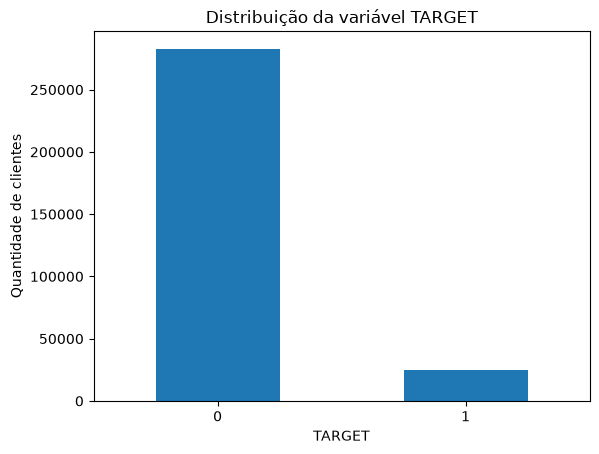

In [7]:
target_freq = (
    df_application["TARGET"]
    .value_counts()
    .rename_axis("TARGET")
    .to_frame("Quantidade")
)

target_freq["Percentual (%)"] = (
    df_application["TARGET"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target_freq["Quantidade"].plot(kind="bar")

plt.title("Distribuição da variável TARGET")
plt.xlabel("TARGET")
plt.ylabel("Quantidade de clientes")
plt.xticks(rotation=0)

plt.show()

### Observações do ```TARGET```
* A maioria (~92%) dos clientes pertence à classe 0, indicando que não houve inadimplência.
* Isso caracteriza um problema de classificação desbalanceado, necessitando maior cautela na escolha de métricas de avaliação e aplicação de técnicas para lidar com esse desbalanceamento.

## 1.2 Variáveis Demográficas

Análise das principais características demográficas dos solicitantes: idade, gênero, escolaridade, estado civil, número de filhos, e tipo de renda.

In [8]:
demograficas = [
    "DAYS_BIRTH",
    "CODE_GENDER",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "CNT_CHILDREN",
    "NAME_INCOME_TYPE",
]

df_application[demograficas].head(15)

,DAYS_BIRTH,CODE_GENDER,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,CNT_CHILDREN,NAME_INCOME_TYPE
0,-9461,M,Secondary / secondary special,Single / not married,0,Working
1,-16765,F,Higher education,Married,0,State servant
2,-19046,M,Secondary / secondary special,Single / not married,0,Working
3,-19005,F,Secondary / secondary special,Civil marriage,0,Working
4,-19932,M,Secondary / secondary special,Single / not married,0,Working
5,-16941,M,Secondary / secondary special,Married,0,State servant
6,-13778,F,Higher education,Married,1,Commercial associate
7,-18850,M,Higher education,Married,0,State servant
8,-20099,F,Secondary / secondary special,Married,0,Pensioner
9,-14469,M,Secondary / secondary special,Single / not married,0,Working


In [9]:
# Verificar nulos 
df_application[demograficas].isna().sum().sort_values(ascending=False)

DAYS_BIRTH             0
CODE_GENDER            0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
CNT_CHILDREN           0
NAME_INCOME_TYPE       0
dtype: int64

In [10]:
# Transformar idade em dias para idade em anos

df_application["IDADE"] = (-df_application["DAYS_BIRTH"] / 365.25).round(1)

### 1.2.1 Idade (```DAYS_BIRTH``` transformado)

Perguntas a considerar:
1. Qual idade média?
2. Existem idades estranhas que solicitaram empréstimos? 
3. Como que a idade relaciona com o TARGET?

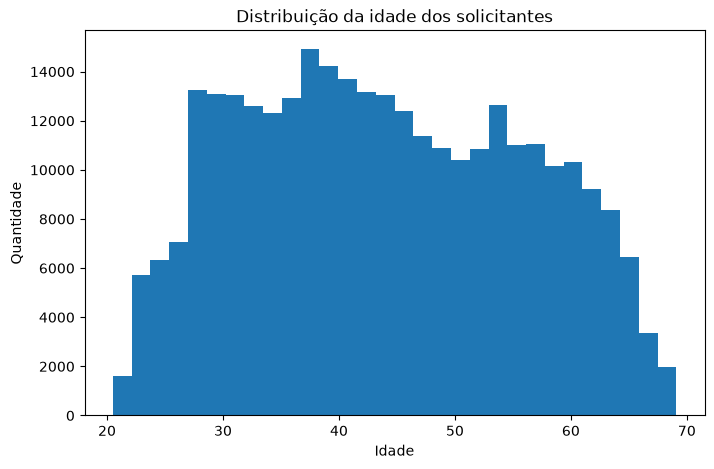

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    df_application["IDADE"],
    bins=30
)

plt.title("Distribuição da idade dos solicitantes")
plt.xlabel("Idade")
plt.ylabel("Quantidade")

plt.show()

In [12]:
df_application.groupby("TARGET")["IDADE"].describe()

,count,mean,std,min,25%,50%,75%,max
TARGET,,,,,,,,
0,282686.0,44.183969,11.948570,20.5,34.3,43.5,54.2,69.1
1,24825.0,40.752709,11.479462,21.0,31.2,39.1,49.4,68.9


In [13]:
df_application.groupby("TARGET")["IDADE"].median()

TARGET
0    43.5
1    39.1
Name: IDADE, dtype: float64

<Figure size 800x600 with 0 Axes>

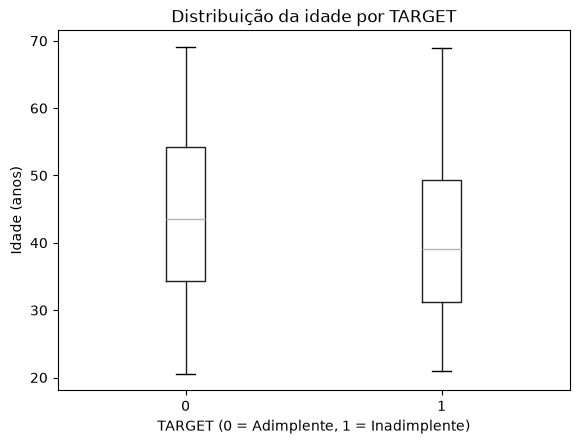

In [14]:
plt.figure(figsize=(8, 6))

df_application.boxplot(
    column="IDADE",
    by="TARGET",
    grid=False
)

plt.title("Distribuição da idade por TARGET")
plt.suptitle("")  # Remove o título automático do pandas
plt.xlabel("TARGET (0 = Adimplente, 1 = Inadimplente)")
plt.ylabel("Idade (anos)")

plt.show()

#### Observações
* Clientes inadimplentes apresentam média e mediana de idade menores. 
* Idade parece ser uma variável relevante para o modelo preditivo.

### 1.2.2 Gênero ```CODE_GENDER```

Perguntas a considerar:
1. Existe diferença na taxa de inadimplência entre homens e mulheres?

In [20]:
df_application["CODE_GENDER"].value_counts()

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

In [22]:
# Proporcionalidade
df_application["CODE_GENDER"].value_counts(normalize=True) * 100

CODE_GENDER
F      65.834393
M      34.164306
XNA     0.001301
Name: proportion, dtype: float64

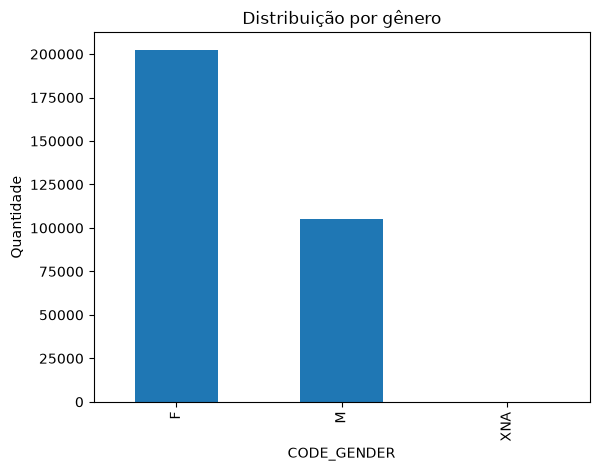

In [ ]:
df_application["CODE_GENDER"].value_counts().plot.bar()

plt.title("Distribuição por gênero")
plt.ylabel("Quantidade")
plt.show()

In [ ]:
genero_target = pd.crosstab(
    df_application["CODE_GENDER"],
    df_application["TARGET"],
    normalize="index"
).round(3)

genero_target

TARGET,0,1
CODE_GENDER,,
F,0.930,0.070
M,0.899,0.101
XNA,1.000,0.000


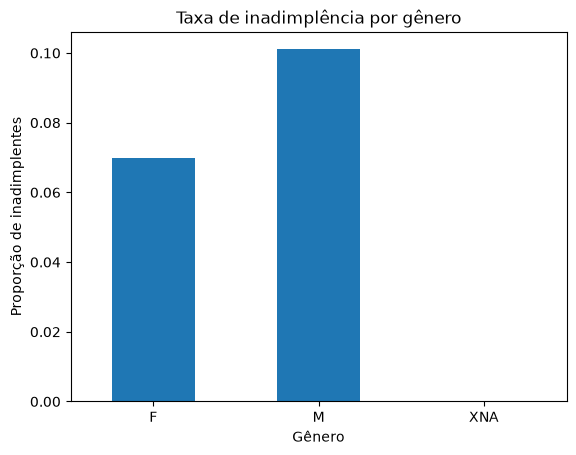

In [26]:
genero_target[1].plot(
    kind="bar"
)

plt.title("Taxa de inadimplência por gênero")
plt.xlabel("Gênero")
plt.ylabel("Proporção de inadimplentes")
plt.xticks(rotation=0)

plt.show()

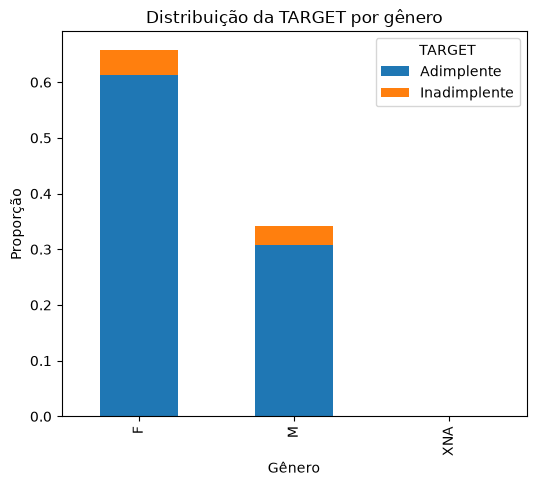

In [32]:
pd.crosstab(
    df_application["CODE_GENDER"],
    df_application["TARGET"],
    normalize="all"
).plot(
    kind="bar",
    stacked=True,
    figsize=(6,5)
)

plt.title("Distribuição da TARGET por gênero")
plt.xlabel("Gênero")
plt.ylabel("Proporção")

plt.legend(
    title="TARGET",
    labels=["Adimplente", "Inadimplente"]
)

plt.show()

#### Observações

* Há somente 4(0.001%) registros com clientes sem declaração de genêro (XNA), possibilidade de removê-los durante a construção da ABT. 
* Mulheres representam 65% dos solicitantes de crédito, mas apresentam uma taxa de inadimplência inferior à observada entre os homens (6.9% entre mulheres e 10.2% entre homens), indicando que a varíavel de gênero ```CODE_GENDER``` pode possuir poder preditivo para o modelo.

### 1.2.3 Escolaridade ```NAME_EDUCATION_TYPE```

Perguntas a considerar:
1. Escolaridade tem alguma relação com a taxa de inadimplência?|
2. Possui potencial para feature engineering?

In [33]:
df_application["NAME_EDUCATION_TYPE"].value_counts()

NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64

In [34]:
(
    df_application["NAME_EDUCATION_TYPE"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

NAME_EDUCATION_TYPE
Secondary / secondary special    71.02
Higher education                 24.34
Incomplete higher                 3.34
Lower secondary                   1.24
Academic degree                   0.05
Name: proportion, dtype: float64

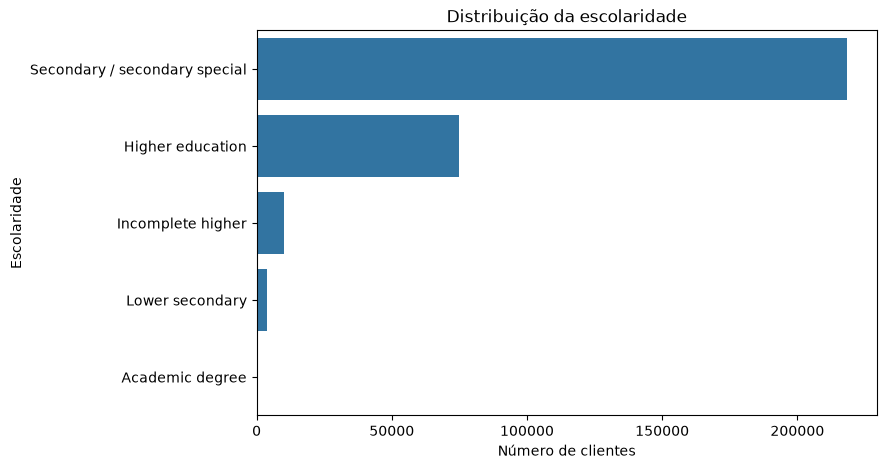

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_application,
    y="NAME_EDUCATION_TYPE",
    order=df_application["NAME_EDUCATION_TYPE"].value_counts().index
)

plt.title("Distribuição da escolaridade")
plt.xlabel("Número de clientes")
plt.ylabel("Escolaridade")

plt.show()

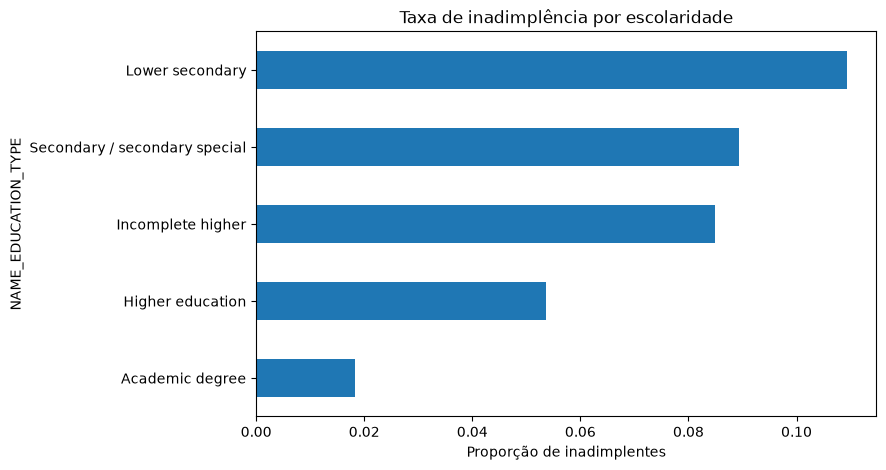

In [37]:
educacao_target = pd.crosstab(
    df_application["NAME_EDUCATION_TYPE"],
    df_application["TARGET"],
    normalize="index"
)

educacao_target[1].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Taxa de inadimplência por escolaridade")
plt.xlabel("Proporção de inadimplentes")

plt.show()

#### Observações

* 95% dos clientes da base possuem ensino secundário (71%) ou ensino superior (24%) indicando a concentração da carteira do grupo. Isso também indica dados desbalanceados no aspecto de educação.
* Observa-se uma possível tendência na taxa de inadimplência entre os níveis de escolaridade, sugerindo que essa variável possui potencial preditivo.
* Feature engineering: podemos considerar agrupamento (secundária, superior, outros) ou uma feature binária (possuí educação superior ou acima?)

### 1.2.4 Estado Civil ```NAME_FAMILY_STATUS```

In [43]:
df_application["NAME_FAMILY_STATUS"].value_counts()

NAME_FAMILY_STATUS
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Unknown                      2
Name: count, dtype: int64

In [44]:
(
    df_application["NAME_FAMILY_STATUS"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

NAME_FAMILY_STATUS
Married                 63.88
Single / not married    14.78
Civil marriage           9.68
Separated                6.43
Widow                    5.23
Unknown                  0.00
Name: proportion, dtype: float64

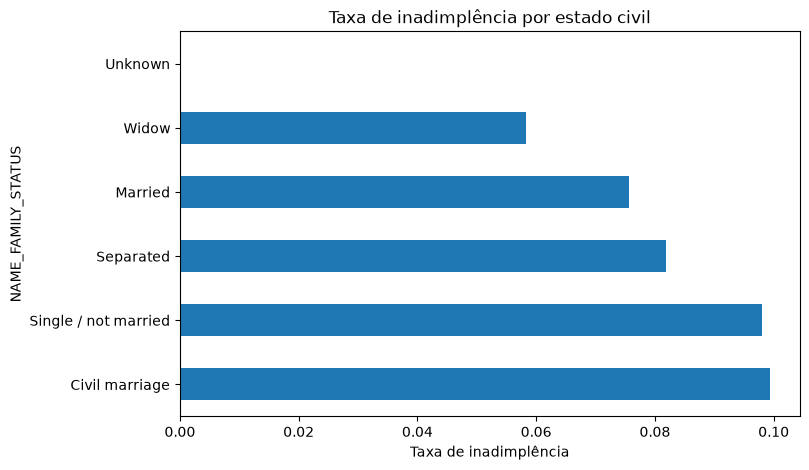

In [46]:
estado_civil = (
    df_application
    .groupby("NAME_FAMILY_STATUS", observed=False)["TARGET"]
    .mean()
    .sort_values(ascending=False)
)

estado_civil.plot(kind="barh", figsize=(8,5))

plt.title("Taxa de inadimplência por estado civil")
plt.xlabel("Taxa de inadimplência")

plt.show()

#### Observações

* Solteiros e uniões civis apresentam uma taxa de inadimplência elevada, indicando possível poder preditivo do modelo.
* A categoria ```unknown``` poderá ser excluida na ABT pois somente contém 2 observações.

### 1.2.5 Número de Filhos ```CNT_CHILDREN```

In [47]:
df_application["CNT_CHILDREN"].value_counts().sort_index()

CNT_CHILDREN
0     215371
1      61119
2      26749
3       3717
4        429
5         84
6         21
7          7
8          2
9          2
10         2
11         1
12         2
14         3
19         2
Name: count, dtype: int64

In [48]:
df_application["CNT_CHILDREN"].describe()

count    307511.000000
mean          0.417052
std           0.722121
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          19.000000
Name: CNT_CHILDREN, dtype: float64

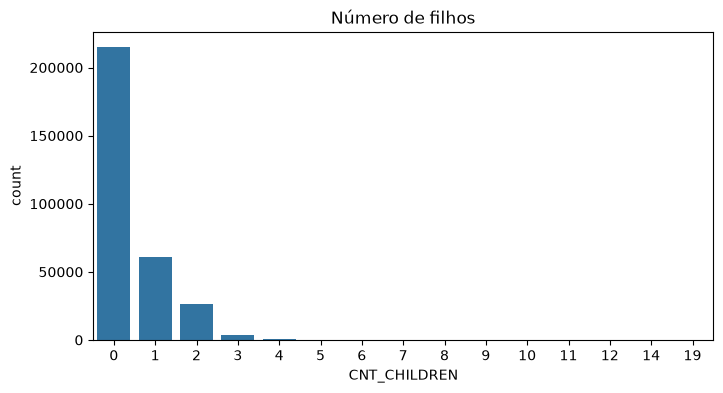

In [49]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=df_application,
    x="CNT_CHILDREN"
)

plt.title("Número de filhos")

plt.show()

In [51]:
filhos = (
    df_application
    .groupby("CNT_CHILDREN", observed=False)["TARGET"]
    .agg(["count","mean"])
)

children_target = (
    df_application
    .groupby("CNT_CHILDREN", observed=False)["TARGET"]
    .agg(
        Clientes="count",
        Taxa_Inadimplencia="mean"
    )
)

children_target

,Clientes,Taxa_Inadimplencia
CNT_CHILDREN,,
0,215371,0.077118
1,61119,0.089236
2,26749,0.087218
3,3717,0.096314
4,429,0.128205
5,84,0.083333
6,21,0.285714
7,7,0.000000
8,2,0.000000


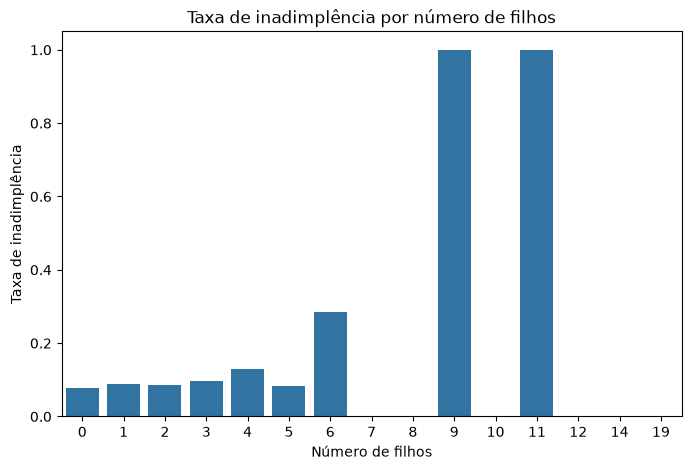

In [52]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=children_target.reset_index(),
    x="CNT_CHILDREN",
    y="Taxa_Inadimplencia"
)

plt.title("Taxa de inadimplência por número de filhos")
plt.xlabel("Número de filhos")
plt.ylabel("Taxa de inadimplência")

plt.show()

#### Observações

* A maioria dos clientes não possuem filhos (~70%)
* Há uma leve tendência no aumento da taxa de inadimplência entre clientes com um número maior de filhos, mas com poucas observações.
* Feature engineering: Podemos agrupar os valores altos que ocorrem raramente, para 4+ filhos.

### 1.2.6 Tipo de Renda ```NAME_INCOME_TYPE```

Perguntas a considerar:
1. Alguns tipos de renda apresentam maior risco? Algumas categorias tendem a ser mais inadimplentes?
2. O tipo de renda está relacionado ao valor da renda? - Cruzamento com a coluna a coluna de renda ```AMT_INCOME_TOTAL```
3. O tipo de renda realmente adiciona informação? Possível colinearidade com a quantidade de renda
4. Feature engineering

In [53]:
df_application["NAME_INCOME_TYPE"].value_counts()

NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

In [54]:
(
    df_application["NAME_INCOME_TYPE"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

NAME_INCOME_TYPE
Working                 51.63
Commercial associate    23.29
Pensioner               18.00
State servant            7.06
Unemployed               0.01
Student                  0.01
Businessman              0.00
Maternity leave          0.00
Name: proportion, dtype: float64

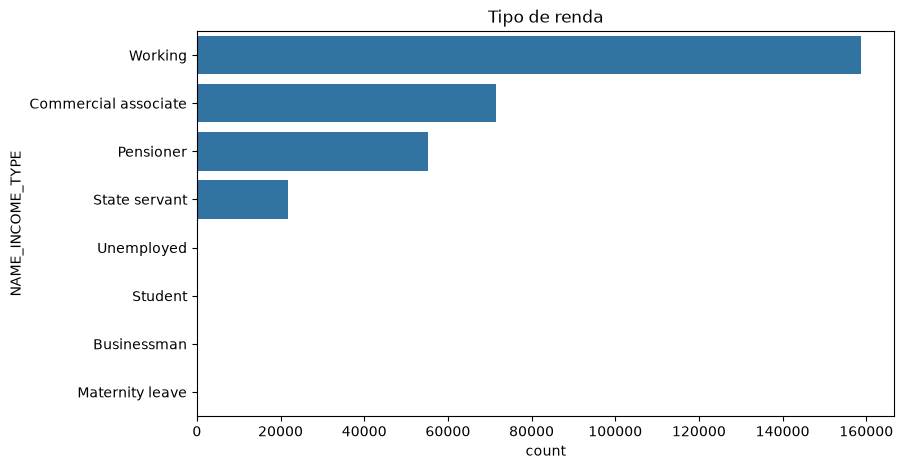

In [55]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df_application,
    y="NAME_INCOME_TYPE",
    order=df_application["NAME_INCOME_TYPE"].value_counts().index
)

plt.title("Tipo de renda")

plt.show()

In [56]:
income_type = (
    df_application
    .groupby("NAME_INCOME_TYPE", observed=False)["TARGET"]
    .mean()
    .sort_values(ascending=False)
)

income_type

NAME_INCOME_TYPE
Maternity leave         0.400000
Unemployed              0.363636
Working                 0.095885
Commercial associate    0.074843
State servant           0.057550
Pensioner               0.053864
Businessman             0.000000
Student                 0.000000
Name: TARGET, dtype: float64

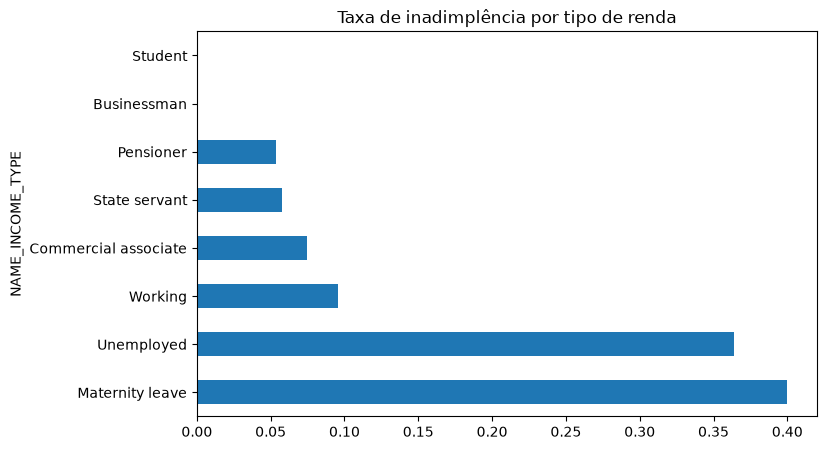

In [57]:
income_type.plot(kind="barh", figsize=(8,5))

plt.title("Taxa de inadimplência por tipo de renda")

plt.show()

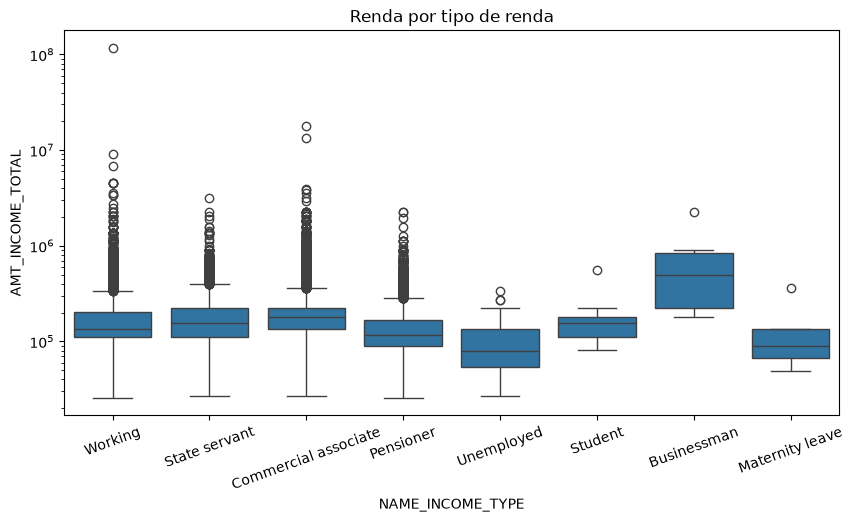

In [58]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df_application,
    x="NAME_INCOME_TYPE",
    y="AMT_INCOME_TOTAL"
)

plt.yscale("log")
plt.xticks(rotation=20)

plt.title("Renda por tipo de renda")

plt.show()

#### Observações

* A maior parte dos clientes (51.6%) estão trabalhando ("Working"), indicando que é o principal perfil da carteira de crédito.
* Outras categorias também possuem representividade significativa.
* Apesar da alta taxa de inadimplência dos clientes em licença de maternidade e desempregados, aparecem com frequência extremamente baixa de <0.01%, junto com estudantes e empresários. 
* Clientes cuja principal fonte de renda é o trabalho assalariado apresentam comportamento diferente de grupos como pensionistas ou servidores públicos, indicando que o tipo de renda pode possuir poder de previsão para o modelo.

## 1.3 Variáveis Financeiras

As variáveis financeiras talvez sejam as mais fortes preditoras seguindo intuição. Todos contém somente valores númericos, e são candidatos para fazer feature engineering.

* Renda, valor do crédito, valor da anuidade, e o valor dos bens.

In [ ]:
financeiras = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
]

# 2 decimais e sem notação científica
pd.set_option('display.float_format', '{:.2f}'.format)

df_application[financeiras].head(10)

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE
0,202500.00,406597.50,24700.50,351000.00
1,270000.00,1293502.50,35698.50,1129500.00
2,67500.00,135000.00,6750.00,135000.00
3,135000.00,312682.50,29686.50,297000.00
4,121500.00,513000.00,21865.50,513000.00
5,99000.00,490495.50,27517.50,454500.00
6,171000.00,1560726.00,41301.00,1395000.00
7,360000.00,1530000.00,42075.00,1530000.00
8,112500.00,1019610.00,33826.50,913500.00
9,135000.00,405000.00,20250.00,405000.00


In [16]:
df_application[financeiras].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.937500,402490.781250,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,27108.572266,14493.737305,1615.5,16524.0,24903.0,34596.0,258025.5
AMT_GOODS_PRICE,307233.0,538396.125000,369446.468750,40500.0,238500.0,450000.0,679500.0,4050000.0


In [119]:
print("Nulos:")
df_application[financeiras].isna().sum().sort_values(ascending=False)

Nulos:


AMT_GOODS_PRICE     278
AMT_ANNUITY          12
AMT_INCOME_TOTAL      0
AMT_CREDIT            0
dtype: int64

### 1.3.1 Renda ```AMT_INCOME_TOTAL```

Perguntas a considerar
1. Como a renda está distribuída?
2. Existem outliers? Como melhor lidar com elas?
3. A renda está associada à taxa de inadimplência?
4. Potencial para feature engineering usando essa variável

In [93]:
df_application["AMT_INCOME_TOTAL"].describe()

count      307511.00
mean       168797.92
std        237123.15
min         25650.00
25%        112500.00
50%        147150.00
75%        202500.00
max     117000000.00
Name: AMT_INCOME_TOTAL, dtype: float64

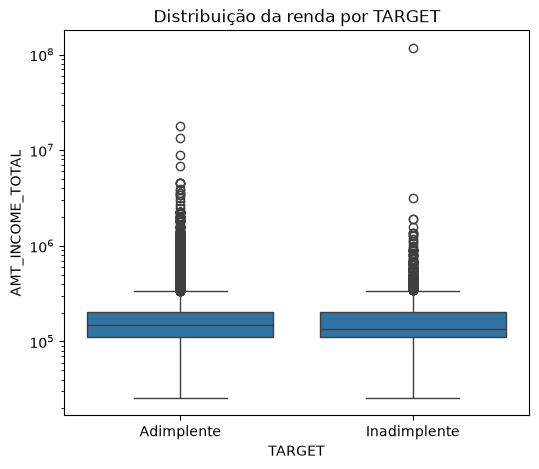

In [97]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df_application,
    x="TARGET",
    y="AMT_INCOME_TOTAL"
)

plt.yscale("log")

plt.xticks([0,1], ["Adimplente", "Inadimplente"])

plt.title("Distribuição da renda por TARGET")

plt.show()

In [ ]:
(
    df_application
    .groupby("TARGET")["AMT_INCOME_TOTAL"]
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
TARGET,,,,,,,,
0,282686.0,169077.722266,110476.268524,25650.0,112500.0,148500.0,202500.0,18000090.0
1,24825.0,165611.760906,746676.959440,25650.0,112500.0,135000.0,202500.0,117000000.0


In [98]:
income_bins = pd.qcut(
    df_application["AMT_INCOME_TOTAL"],
    q=10
)

(
    df_application
    .groupby(income_bins, observed=False)["TARGET"]
    .mean()
)

AMT_INCOME_TOTAL
(25649.999, 81000.0]      0.08
(81000.0, 99000.0]        0.08
(99000.0, 112500.0]       0.09
(112500.0, 135000.0]      0.08
(135000.0, 147150.0]      0.09
(147150.0, 162000.0]      0.09
(162000.0, 180000.0]      0.08
(180000.0, 225000.0]      0.08
(225000.0, 270000.0]      0.07
(270000.0, 117000000.0]   0.06
Name: TARGET, dtype: float64

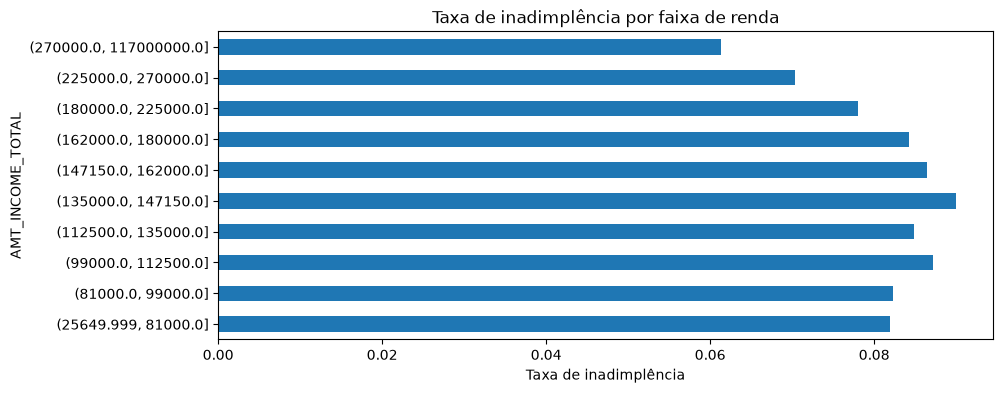

In [99]:
(
    df_application
    .groupby(income_bins, observed=False)["TARGET"]
    .mean()
).plot(
    kind="barh",
    figsize=(10,4)
)

plt.xlabel("Taxa de inadimplência")
plt.title("Taxa de inadimplência por faixa de renda")

plt.show()

In [100]:
df_application["AMT_INCOME_TOTAL"].quantile(0.99)

472500.0

#### Observações

* Foram identificados alguns outliers de renda, afetando medidas de média e dificultando a visualização. 
* A mediana seria melhor para representar a renda típica.
* Grande parte dos clientes estão concentradas em faixas de renda mais baixas: cauda longa à direita.
* Há uma diferença na distribuição de renda entre clientes adimplentes e inadimplentes sugerindo possibilidade de poder preditivo.
* Bom candidato para feature engineering com outras variáveis financeiras.

### 1.3.2 Valor do Crédito ```AMT_CREDIT```

O valor do empréstimo. 

Perguntas a considerar: 
1. Como o valor do crédito está distribuído?
2. Existem outliers?
3. Clientes inadimplentes tendem a solicitar créditos maiores ou menores?
4. Existe relação entre valor do crédito e renda?

In [101]:
df_application["AMT_CREDIT"].describe()

count    307511.00
mean     599025.94
std      402490.78
min       45000.00
25%      270000.00
50%      513531.00
75%      808650.00
max     4050000.00
Name: AMT_CREDIT, dtype: float64

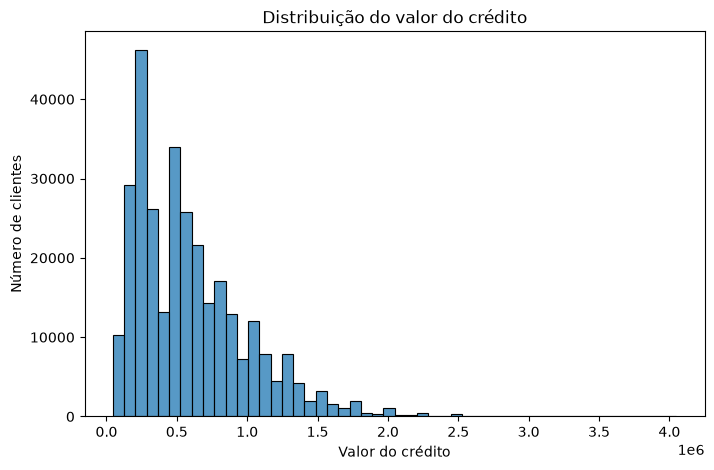

In [103]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_application,
    x="AMT_CREDIT",
    bins=50
)

plt.title("Distribuição do valor do crédito")
plt.xlabel("Valor do crédito")
plt.ylabel("Número de clientes")

plt.show()

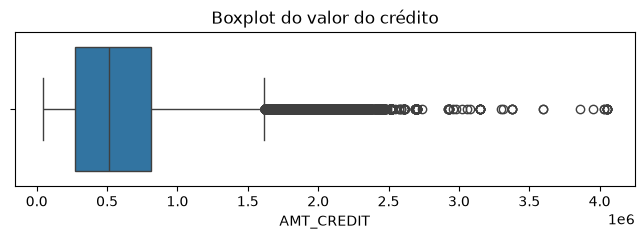

In [ ]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df_application["AMT_CREDIT"]
)

plt.title("Boxplot do valor do crédito")

plt.show()

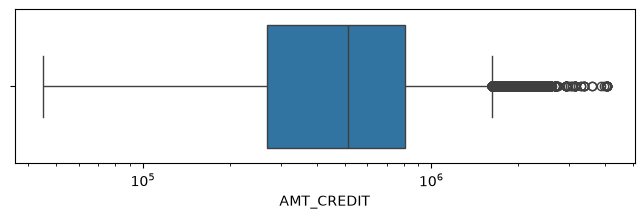

In [90]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df_application["AMT_CREDIT"]
)

plt.xscale("log")

plt.show()

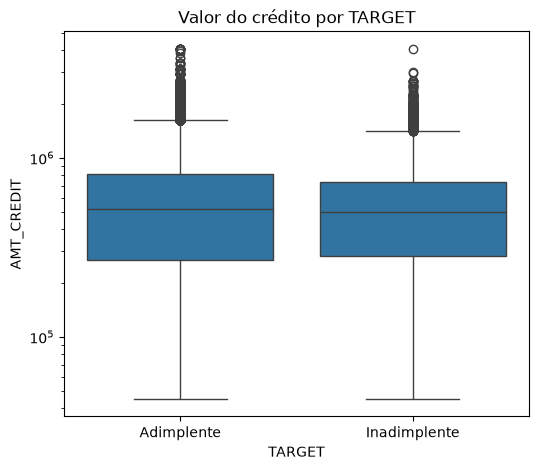

In [105]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df_application,
    x="TARGET",
    y="AMT_CREDIT"
)

plt.yscale("log")

plt.xticks([0,1], ["Adimplente", "Inadimplente"])

plt.title("Valor do crédito por TARGET")

plt.show()

In [113]:
credit_bins = pd.qcut(
    df_application["AMT_CREDIT"],
    q=10,
    duplicates="drop"
)

default_credit = (
    df_application
    .groupby(credit_bins, observed=False)["TARGET"]
    .mean()
)

default_credit

AMT_CREDIT
(44999.999, 180000.0]    0.07
(180000.0, 254700.0]     0.08
(254700.0, 306306.0]     0.08
(306306.0, 432000.0]     0.10
(432000.0, 513531.0]     0.10
(513531.0, 604152.0]     0.11
(604152.0, 755190.0]     0.09
(755190.0, 900000.0]     0.07
(900000.0, 1133748.0]    0.07
(1133748.0, 4050000.0]   0.05
Name: TARGET, dtype: float64

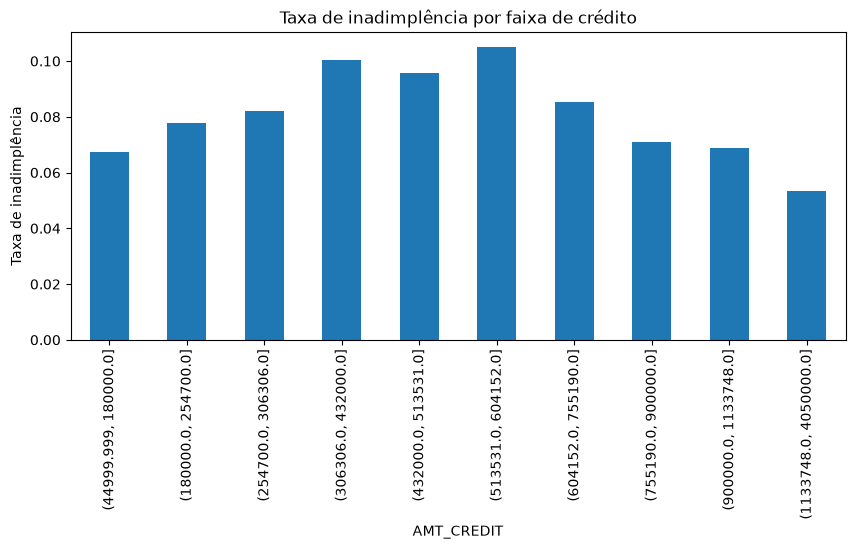

In [110]:
plt.figure(figsize=(10,4))

default_credit.plot(kind="bar")

plt.ylabel("Taxa de inadimplência")
plt.title("Taxa de inadimplência por faixa de crédito")

plt.show()

In [106]:
(
    df_application
    .groupby("TARGET")["AMT_CREDIT"]
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
TARGET,,,,,,,,
0,282686.00,602648.31,406845.91,45000.00,270000.00,517788.00,810000.00,4050000.00
1,24825.00,557778.50,346433.25,45000.00,284400.00,497520.00,733315.50,4027680.00


#### Observações

* A distribuição do valor do crédito está mais concentrada em valores menores.
* Presença de outliers, mas menos pronunciados do que na renda.
* Essa varíavel isoladamente parece não ter um poder preditivo significativo. 
* Feature engineering: excelente candidato para uma nova feature ```CREDIT_INCOME_RATIO = AMT_CREDIT / AMT_INCOME_TOTAL```

### 1.3.3 Valor da Anuidade ```AMT_ANNUITY```

As anuidades são os pagamentos que o cliente faz. O cliente não paga o empréstimo inteiro em uma vez.

In [116]:
df_application["AMT_ANNUITY"].describe(
    percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]
).to_frame().T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
AMT_ANNUITY,307499.00,27108.57,14493.74,1615.50,6182.91,9000.00,16524.00,24903.00,34596.00,53325.00,70006.50,258025.50


In [120]:
df_application["AMT_ANNUITY"].isna().mean() * 100

0.003902299429939092

In [126]:
matrix = df_application[financeiras].corr()
print(matrix)

                  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE
AMT_INCOME_TOTAL              1.00        0.16         0.19             0.16
AMT_CREDIT                    0.16        1.00         0.77             0.99
AMT_ANNUITY                   0.19        0.77         1.00             0.78
AMT_GOODS_PRICE               0.16        0.99         0.78             1.00


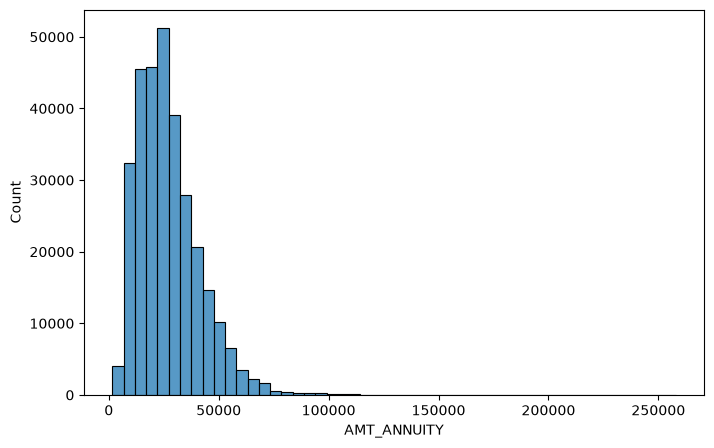

In [121]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_application,
    x="AMT_ANNUITY",
    bins=50
)

plt.show()

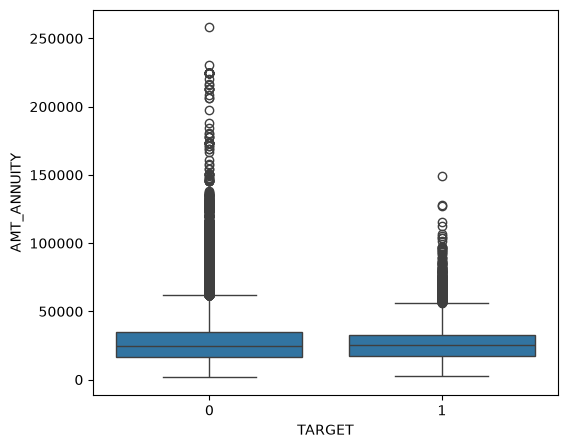

In [122]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df_application,
    x="TARGET",
    y="AMT_ANNUITY"
)

plt.show()

In [124]:
df_application.groupby("TARGET")["AMT_ANNUITY"].agg(
    ["count","mean","median"]
)

,count,mean,median
TARGET,,,
0,282674,27163.62,24876.00
1,24825,26481.74,25263.00


#### Observações

* As anuidades seguem um padrão similar à do crédito, com uma correlação alta. A maioria dos dados estão concentrados em valores menores.
* Clientes adimplentes e inadimplentes apresentam distribuições semelhantes, indicando capacidade limitade de predição de clientes inadimplentes.
* 12 valores nulos, que podem ser tratados com imputação de mediana.

### 1.3.4 Valor dos Bens ```AMT_GOODS_PRICE```

O valor do bem financiado, complementando ```AMT_CREDIT``` e ```AMT_ANNUITY```. 

In [127]:
df_application["AMT_GOODS_PRICE"].describe(
    percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]
).to_frame().T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
AMT_GOODS_PRICE,307233.00,538396.12,369446.47,40500.00,67500.00,135000.00,238500.00,450000.00,679500.00,1305000.00,1800000.00,4050000.00


In [139]:
goodsprice_null_count = df_application["AMT_GOODS_PRICE"].isna().sum()

goodsprice_null_pct = df_application["AMT_GOODS_PRICE"].isna().mean() * 100

print(
    f"Quantidade de nulos: {goodsprice_null_count}\n"
    f"Percentual: {goodsprice_null_pct:.2f}%"
)

Quantidade de nulos: 278
Percentual: 0.09%


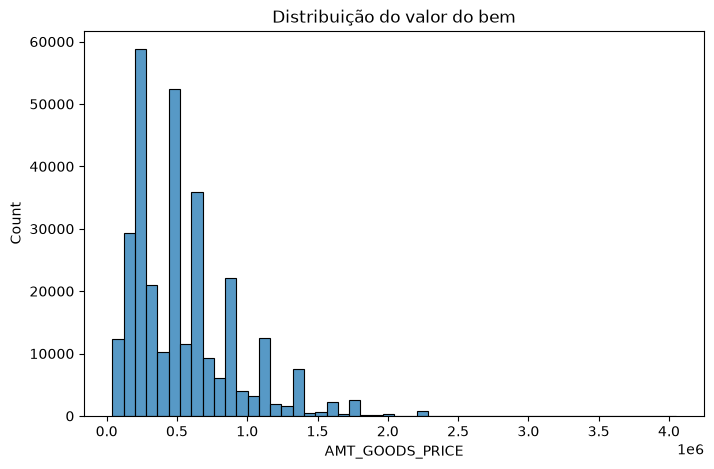

In [140]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_application,
    x="AMT_GOODS_PRICE",
    bins=50
)

plt.title("Distribuição do valor do bem")
plt.show()

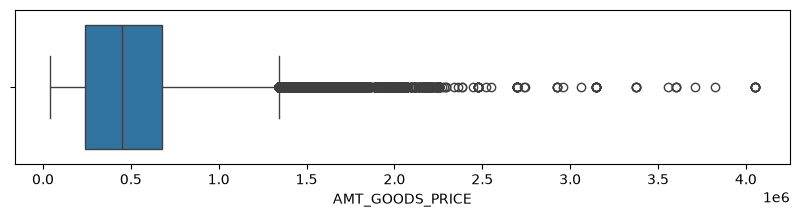

In [141]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df_application["AMT_GOODS_PRICE"]
)

plt.show()

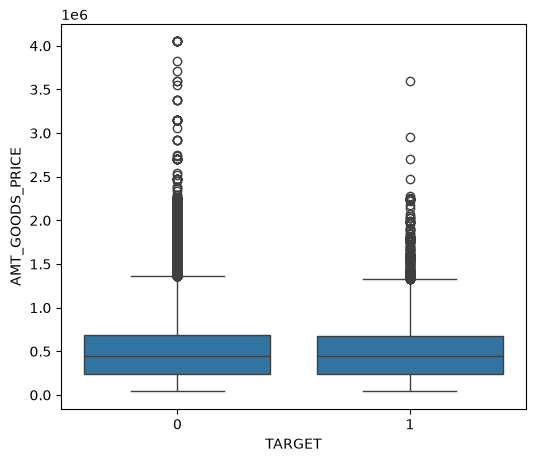

In [143]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df_application,
    x="TARGET",
    y="AMT_GOODS_PRICE"
)

plt.show()

In [148]:
df_application.groupby("TARGET")["AMT_GOODS_PRICE"].describe()

,count,mean,std,min,25%,50%,75%,max
TARGET,,,,,,,,
0,282429.00,542736.88,373785.50,40500.00,238500.00,450000.00,688500.00,4050000.00
1,24804.00,488972.44,311636.50,45000.00,238500.00,450000.00,675000.00,3600000.00


#### Observações

* Como as outras variáveis financeiras, esta distribuição também é fortemente assimétrica à direita, concentrando os financiamentos em bens de menor valor.
* Clientes adimplentes e inadimplentes apresentam distribuições semelhantes, indicando que essa variável isoladamente não tem um poder preditivo significativo.
* As medianas são iguais para clientes adimplentes e inadimplentes.
* As médias são elevadas para clientes adimplentes, possivelmente por causa dos outliers.

### 1.3.5 Possíveis Novas Features - Exploração

3 das 4 variáveis isoladamente indicaram baixo poder preditivo, mas são essênciais para o negócio pois são dados financeiros concretos.

##### 1.3.5.1 Credit to Income Ratio

A intuição é que valores altos indicariam um comprometimento financeiro maior e por isso talvez um risco maior de inadimplência.

In [149]:
df_application["CREDIT_INCOME_RATIO"] = (
    df_application["AMT_CREDIT"] /
    df_application["AMT_INCOME_TOTAL"]
)

In [150]:
df_application.groupby("TARGET")["CREDIT_INCOME_RATIO"].describe()

,count,mean,std,min,25%,50%,75%,max
TARGET,,,,,,,,
0,282686.00,3.96,2.70,0.04,2.00,3.27,5.19,49.23
1,24825.00,3.89,2.63,0.00,2.13,3.25,4.99,84.74


<Axes: xlabel='TARGET', ylabel='CREDIT_INCOME_RATIO'>

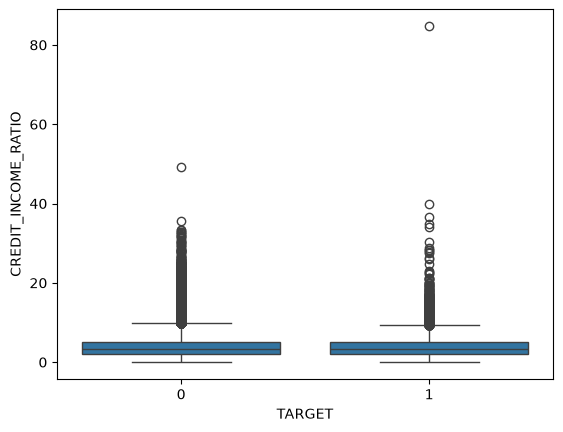

In [151]:
sns.boxplot(
    data=df_application,
    x="TARGET",
    y="CREDIT_INCOME_RATIO"
)

##### 1.3.5.2 Annuity to Income Ratio

Quanto da renda é necessária para pagar as parcelas. Representaria a capacidade de pagamento.

##### 1.3.5.3 Credit to Goods Ratio

Mostra qual porcentagem do bem foi fnanciado. Alguns clientes podem dar um valor de entrada. Outros clientes que financiam 100% do bem podem apresentar um perfil mais arriscado.

## 1.4 Variáveis de Emprego

In [17]:
emprego = [
    "DAYS_EMPLOYED",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE",
]

### 1.4.1 Tempo Empregado ```DAYS_EMPLOYED```

#### Observações

### 1.4.2 Tipo de Ocupação ```OCCUPATION_TYPE```

#### Observações

### 1.4.3 Tipo de Organização ```ORGANIZATION_TYPE```

#### Observações

## 1.5 Variáveis de Habitação

In [18]:
habitacao = [
    "FLAG_OWN_REALTY",
    "NAME_HOUSING_TYPE",
]

### 1.5.1 Possui imóvel? (BOOL) ```FLAG_OWN_REALTY```

#### Observações

### 1.5.2 Tipo de Habitação ```NAME_HOUSING_TYPE```

#### Observações

## 1.6 Scores externos

In [19]:
scores_externos = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
]

# 2. Analisando a base secundária ```bureau```

# 3. Analisando a base ```previous_application```